In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
import numpy as np
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

In [3]:
# Create mass-action reactions
r1 = MassAction([], ['Z_1'], ['u_1'], [10.])
r2 = MassAction(['X_2'], ['X_2', 'Z_2'], [None], [1])
r3 = MassAction(['Z_1', 'Z_2'], [], [None], [0.01])
r4 = MassAction(['Z_1'], ['Z_1', 'X_1'], [None], [10])
r5 = MassAction(['X_1'], ['X_1', 'X_2'], [None], [0.1])
r6 = MassAction(['X_1'], [], ['u_2'], [4.])
r7 = MassAction(['X_2'], [], ['u_3'], [1.])

In [4]:
# Create and compile the IOCRN
iocrn = IOCRN(reactions=[r1, r2, r3, r4, r5, r6, r7], output_labels=['X_2', 'X_1'])
iocrn.compile()
print(iocrn)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2', 'X_1'] 
∅ ----> Z_1;  [MAK(10.0, u_1)]
X_2 ----> X_2 + Z_2;  [MAK(1)]
Z_1 + Z_2 ----> ∅;  [MAK(0.01)]
Z_1 ----> X_1 + Z_1;  [MAK(10)]
X_1 ----> X_1 + X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(4.0, u_2)]
X_2 ----> ∅;  [MAK(1.0, u_3)]


In [5]:
# Print the indices of the species, inputs, and outputs
print("Species indices:", iocrn.species_idx_dict)
print("Input indices:", iocrn.input_idx_dict)
print("Output indices:", iocrn.output_idx)

# Mapping from labels to indices
print(iocrn.species_label_to_idx('X_1'))
print(iocrn.species_label_to_idx(['X_1', 'Z_2']))
print(iocrn.input_label_to_idx('u_2'))

Species indices: {'X_1': 0, 'X_2': 1, 'Z_1': 2, 'Z_2': 3}
Input indices: {'u_1': 0, 'u_2': 1, 'u_3': 2}
Output indices: [1 0]
0
[0, 3]
1


In [6]:
# Print the stoichiometry matrix
print(iocrn.S)

[[ 0.  0.  0.  1.  0. -1.  0.]
 [ 0.  0.  0.  0.  1.  0. -1.]
 [ 1.  0. -1.  0.  0.  0.  0.]
 [ 0.  1. -1.  0.  0.  0.  0.]]


In [7]:
# Test the Propensity Functions
x = np.array([10, 5, 2, 3]) # X_1, X_2, Z_1, Z_2
u = np.array([0.8, 0.1, 0.2])       # u_1, u_2, u_3
print(iocrn.propensity_function(x, u))

[ 8.    5.    0.06 20.    1.    4.    1.  ]


In [8]:
# Test the Rate Functions
print(iocrn.rate_function(0, x, u))

[16.    0.    7.94  4.94]


In [9]:
# Gather reaction parameters and IDs
print(iocrn.gather_reaction_params())
print(iocrn.gather_reaction_IDs())

[[10.0], [1], [0.01], [10], [0.1], [4.0], [1.0]]
[None, None, None, None, None, None, None]


In [10]:
# Construct initial conditions
ic = IC(iocrn.species_labels, values= [
    [0, 0, 0, 0],
    [20, 20, 20, 20],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0, 0, 0, 0]), array([20, 20, 20, 20])]


In [11]:
# Construct inputs
input_values = [0.5, 1.0, 1.5]
u_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=iocrn.num_inputs)]
print(u_list)

[array([0.5, 0.5, 0.5], dtype=float32), array([0.5, 0.5, 1. ], dtype=float32), array([0.5, 0.5, 1.5], dtype=float32), array([0.5, 1. , 0.5], dtype=float32), array([0.5, 1. , 1. ], dtype=float32), array([0.5, 1. , 1.5], dtype=float32), array([0.5, 1.5, 0.5], dtype=float32), array([0.5, 1.5, 1. ], dtype=float32), array([0.5, 1.5, 1.5], dtype=float32), array([1. , 0.5, 0.5], dtype=float32), array([1. , 0.5, 1. ], dtype=float32), array([1. , 0.5, 1.5], dtype=float32), array([1. , 1. , 0.5], dtype=float32), array([1., 1., 1.], dtype=float32), array([1. , 1. , 1.5], dtype=float32), array([1. , 1.5, 0.5], dtype=float32), array([1. , 1.5, 1. ], dtype=float32), array([1. , 1.5, 1.5], dtype=float32), array([1.5, 0.5, 0.5], dtype=float32), array([1.5, 0.5, 1. ], dtype=float32), array([1.5, 0.5, 1.5], dtype=float32), array([1.5, 1. , 0.5], dtype=float32), array([1.5, 1. , 1. ], dtype=float32), array([1.5, 1. , 1.5], dtype=float32), array([1.5, 1.5, 0.5], dtype=float32), array([1.5, 1.5, 1. ], dtyp

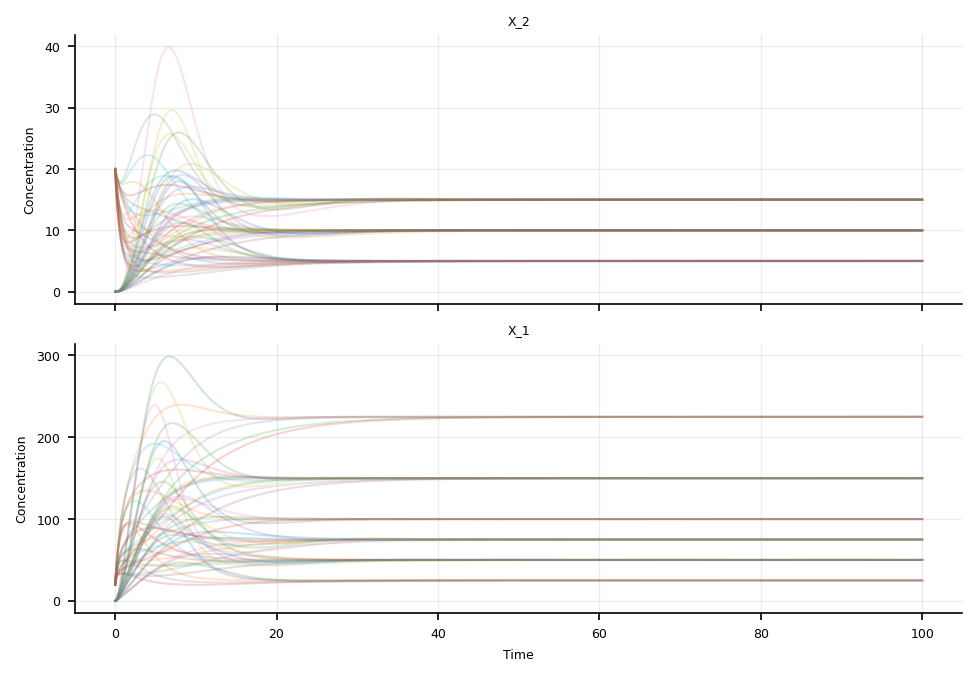

In [12]:
# Simulate Dynamics
time_horizon = np.linspace(0, 100.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)

# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 0.2)

In [13]:
# Construct mass-action reaction library with an extra species
species = ['X_1', 'X_2', 'X_3', 'Z_1', 'Z_2']
reaction_library = construct_mass_action_library(species, 2)
print(reaction_library)

Number of reactions: 421
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> Z_1;  [MAK(None)]
R5: ∅ ----> Z_2;  [MAK(None)]
R6: ∅ ----> X_1 + X_1;  [MAK(None)]
R7: ∅ ----> X_1 + X_2;  [MAK(None)]
R8: ∅ ----> X_1 + X_3;  [MAK(None)]
R9: ∅ ----> X_1 + Z_1;  [MAK(None)]
R10: ∅ ----> X_1 + Z_2;  [MAK(None)]
R11: ∅ ----> X_2 + X_2;  [MAK(None)]
R12: ∅ ----> X_2 + X_3;  [MAK(None)]
R13: ∅ ----> X_2 + Z_1;  [MAK(None)]
R14: ∅ ----> X_2 + Z_2;  [MAK(None)]
R15: ∅ ----> X_3 + X_3;  [MAK(None)]
R16: ∅ ----> X_3 + Z_1;  [MAK(None)]
R17: ∅ ----> X_3 + Z_2;  [MAK(None)]
R18: ∅ ----> Z_1 + Z_1;  [MAK(None)]
R19: ∅ ----> Z_1 + Z_2;  [MAK(None)]
R20: ∅ ----> Z_2 + Z_2;  [MAK(None)]
R21: X_1 ----> ∅;  [MAK(None)]
R22: X_1 ----> X_2;  [MAK(None)]
R23: X_1 ----> X_3;  [MAK(None)]
R24: X_1 ----> Z_1;  [MAK(None)]
R25: X_1 ----> Z_2;  [MAK(None)]
R26: X_1 ----> X_1 + X_1;  [MAK(None)]
R27: X_1 ----> X_1 + X_2;  [MAK(None)]
R28: 

In [14]:
# Add two reactions to the IOCRN
r8 = MassAction(['Z_1'], [], [None], [0.001])
r9 = MassAction(['Z_2'], [], [None], [0.001])
iocrn.add_reaction(r8)
iocrn.add_reaction(r9)
iocrn.compile()
iocrn.reset()
print(iocrn)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2', 'X_1'] 
∅ ----> Z_1;  [MAK(10.0, u_1)]
X_2 ----> X_2 + Z_2;  [MAK(1)]
Z_1 + Z_2 ----> ∅;  [MAK(0.01)]
Z_1 ----> X_1 + Z_1;  [MAK(10)]
X_1 ----> X_1 + X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(4.0, u_2)]
X_2 ----> ∅;  [MAK(1.0, u_3)]
Z_1 ----> ∅;  [MAK(0.001)]
Z_2 ----> ∅;  [MAK(0.001)]


In [15]:
# Set library context
iocrn.set_library_context(reaction_library)

In [16]:
# Print the indices of the species, inputs, and outputs
print("Species indices:", iocrn.species_idx_dict)
print("Input indices:", iocrn.input_idx_dict)
print("Output indices:", iocrn.output_idx)

# Mapping from labels to indices
print(iocrn.species_label_to_idx('X_1'))
print(iocrn.species_label_to_idx(['X_1', 'Z_2']))
print(iocrn.input_label_to_idx('u_2'))

Species indices: {'X_1': 0, 'X_2': 1, 'Z_1': 2, 'Z_2': 3}
Input indices: {'u_1': 0, 'u_2': 1, 'u_3': 2}
Output indices: [1 0]
0
[0, 3]
1


In [17]:
# Print the stoichiometry matrix
print(iocrn.S)

[[ 0.  0.  0.  1.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0. -1.  0.  0.]
 [ 1.  0. -1.  0.  0.  0.  0. -1.  0.]
 [ 0.  1. -1.  0.  0.  0.  0.  0. -1.]]


In [18]:
# Test the Propensity Functions
x = np.array([10, 5, 2, 3]) # X_1, X_2, Z_1, Z_2
u = np.array([0.8, 0.1, 0.2])       # u_1, u_2, u_3
print(iocrn.propensity_function(x, u))

[8.e+00 5.e+00 6.e-02 2.e+01 1.e+00 4.e+00 1.e+00 2.e-03 3.e-03]


In [19]:
# Test the Rate Functions
print(iocrn.rate_function(0, x, u))

[16.     0.     7.938  4.937]


In [20]:
# Gather reaction parameters and IDs
print(iocrn.gather_reaction_params())
print(iocrn.gather_reaction_IDs())

[[10.0], [1], [0.01], [10], [0.1], [4.0], [1.0], [0.001], [0.001]]
[4, 54, 381, 89, 27, 21, 41, 81, 101]


In [21]:
# Construct initial conditions with new species
ic = IC(iocrn.species_labels, values= [
    [0, 0, 0, 0, 0],
    [20, 20, 20, 20, 20],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0, 0, 0, 0]), array([20, 20, 20, 20])]


In [22]:
# Simulate Dynamics
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)

# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 0.2)

In [23]:
# Add reactions with new species
r10 = MassAction(['X_2'], ['X_2', 'X_3'], [None], [0.1])
r11 = MassAction(['X_3'], [], [None], [1])
r12 = MassAction(['X_3', 'X_1'], ['X_3'], [None], [1])
iocrn.add_reaction(r10)
iocrn.add_reaction(r11)
iocrn.add_reaction(r12)
iocrn.compile()
iocrn.reset()
iocrn.set_library_context(reaction_library)
print(iocrn)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'X_3', 'Z_1', 'Z_2'] 
Output Species: ['X_2', 'X_1'] 
∅ ----> Z_1;  [MAK(10.0, u_1)]
X_1 ----> ∅;  [MAK(4.0, u_2)]
X_1 ----> X_1 + X_2;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(1.0, u_3)]
X_2 ----> X_2 + X_3;  [MAK(0.1)]
X_2 ----> X_2 + Z_2;  [MAK(1)]
X_3 ----> ∅;  [MAK(1)]
Z_1 ----> ∅;  [MAK(0.001)]
Z_1 ----> X_1 + Z_1;  [MAK(10)]
Z_2 ----> ∅;  [MAK(0.001)]
X_1 + X_3 ----> X_3;  [MAK(1)]
Z_1 + Z_2 ----> ∅;  [MAK(0.01)]


In [24]:
# Print the indices of the species, inputs, and outputs
print("Species indices:", iocrn.species_idx_dict)
print("Input indices:", iocrn.input_idx_dict)
print("Output indices:", iocrn.output_idx)

# Mapping from labels to indices
print(iocrn.species_label_to_idx('X_1'))
print(iocrn.species_label_to_idx(['X_3', 'Z_2']))
print(iocrn.input_label_to_idx('u_2'))

Species indices: {'X_1': 0, 'X_2': 1, 'X_3': 2, 'Z_1': 3, 'Z_2': 4}
Input indices: {'u_1': 0, 'u_2': 1, 'u_3': 2}
Output indices: [1 0]
0
[2, 4]
1


In [25]:
# Print the stoichiometry matrix
print(iocrn.S)

[[ 0.  0.  0.  1.  0. -1.  0.  0.  0.  0.  0. -1.]
 [ 0.  0.  0.  0.  1.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.]
 [ 1.  0. -1.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  1. -1.  0.  0.  0.  0.  0. -1.  0.  0.  0.]]


In [26]:
# Test the Propensity Functions
x = np.array([10, 5, 1, 2, 3]) # X_1, X_2, X_3, Z_1, Z_2
u = np.array([0.8, 0.1, 0.2])       # u_1, u_2, u_3
print(iocrn.propensity_function(x, u))

[8.e+00 5.e+00 6.e-02 2.e+01 1.e+00 4.e+00 1.e+00 2.e-03 3.e-03 5.e-01
 1.e+00 1.e+01]


In [27]:
# Test the Rate Functions
print(iocrn.rate_function(0, x, u))

[ 6.     0.    -0.5    7.938  4.937]


In [28]:
# Gather reaction parameters and IDs
print(iocrn.gather_reaction_params())
print(iocrn.gather_reaction_IDs())

[[10.0], [1], [0.01], [10], [0.1], [4.0], [1.0], [0.001], [0.001], [0.1], [1], [1]]
[4, 54, 381, 89, 27, 21, 41, 81, 101, 52, 61, 164]


In [29]:
# Construct initial conditions with new species
ic = IC(iocrn.species_labels, values= [
    [0, 0, 0, 0, 0],
    [20, 20, 20, 20, 20],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)


[array([0, 0, 0, 0, 0]), array([20, 20, 20, 20, 20])]


In [30]:
# Simulate Dynamics
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)

# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 0.2)